In [130]:
%reset 

In [131]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import spectral as spy
import re
import matplotlib.colors as mcolors
from pyLRT import RadTran, get_lrt_folder
from scipy.interpolate import interp1d
import matplotlib.cm as cm
from multiprocessing.pool import Pool
#from scipy.interpolate import griddata
from scipy.spatial import Delaunay, cKDTree
from scipy.interpolate import PchipInterpolator
#
#X:\Dropbox\2024_Heron_Campaign\2024_Hyperspec\Processed\20241208_8\ATCOR
base_dir = "/mnt/t/Dropbox/"
#2024_Heron_Campaign/2024_Hyperspec/Processed
sensor_dir= "/mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Calibration and Sensormodel/atcor4/sensors/hyspex_vnir_swir_vs620"
#processed_dir = "2024_Campaign/2024_Hyperspec/Processed"
processed_dir = "2024_Heron_Campaign/2024_Hyperspec/Processed"
#processed_dir = "2025_Fieldwork/2025_Hyperspec/Processed"
filter_dir = "/mnt/t/Dropbox/2025_Fieldwork/2025_Hyperspec/Calibration and Sensormodel/atcor4/sensors/hyspex_vnir_swir_vs620" # folder containing camera bands

#image_dir = "2025_Fieldwork/2025_Hyperspec/Processed/20250213_5"


In [132]:
# The full path containing all session folders
root_path = os.path.join(base_dir, processed_dir)

# Find all images.csv files inside */metadata/images.csv
csv_paths = glob.glob(os.path.join(root_path, "*", "metadata", "images.csv"))
print(root_path)
print("Found CSVs:")
for p in csv_paths:
    print("  ", p)

# Storage for each session's metadata DataFrame
all_meta = []

for csv_path in csv_paths:
    # Extract session_id from the parent folder of "metadata"
    session_id = os.path.basename(os.path.dirname(os.path.dirname(csv_path)))

    # Read the images.csv
    df = pd.read_csv(csv_path)

    # Add session_id column
    df["session_id"] = session_id

    all_meta.append(df)

# Combine into one DataFrame
flightdata = pd.concat(all_meta, ignore_index=True)

def extract_image_id(path: str) -> str | None:
    """
    From a Windows-style path like:
      'T:\\...\\20240203_1_2_01_Mjolnir_S620_SN7018_raw.hyspex'
    return:
      '20240203_1_2_01'
    """

    if not isinstance(path, str):
        return None

    # 1) Normalise to forward slashes so it works in WSL/Linux
    norm = path.replace("\\", "/")

    # 2) Take just the last component (the filename)
    fname = norm.rsplit("/", 1)[-1]
    #    → '20240203_1_2_01_Mjolnir_S620_SN7018_raw.hyspex'

    # 3) Strip the extension (optional but clean)
    fname_no_ext = fname.split(".", 1)[0]
    #    → '20240203_1_2_01_Mjolnir_S620_SN7018_raw'

    # 4) Everything before '_Mjolnir' is the image_id
    return fname_no_ext.split("_Mjolnir", 1)[0]
# Apply to dataframe
flightdata["image_id"] = flightdata["image_path"].apply(extract_image_id)


/mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Processed
Found CSVs:
   /mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Processed/20241203_4/metadata/images.csv
   /mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Processed/20241208_2/metadata/images.csv
   /mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Processed/20241208_1/metadata/images.csv
   /mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Processed/20241208_7/metadata/images.csv
   /mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Processed/20241208_8/metadata/images.csv


In [133]:
flightdata

,image_path,scene,file_size,samples,lines,bands,frame_time,integ_time,utc_start,utc_end,...,pixel_size,azimuth,zenith,red,green,blue,dsm_path,nav_file,session_id,image_id
0,T:\2024_Heron_Campaign\2024_Hyperspec\Recordin...,NaN,3979.00,1392,3047,488,8000,7801,2024-12-03 01:10:29,2024-12-03 01:10:53,...,0.44,81.156574,7.439378,186,115,46,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,20241203_4,20241203_4_01
1,T:\2024_Heron_Campaign\2024_Hyperspec\Recordin...,NaN,22204.97,1392,17114,488,8000,7801,2024-12-03 01:13:51,2024-12-03 01:16:08,...,0.43,80.193135,6.631695,186,115,46,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,20241203_4,20241203_4_02
2,T:\2024_Heron_Campaign\2024_Hyperspec\Recordin...,NaN,15260.27,1392,11754,488,8000,7801,2024-12-03 01:19:05,2024-12-03 01:20:40,...,0.47,77.290708,5.389952,186,115,46,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,20241203_4,20241203_4_03
3,T:\2024_Heron_Campaign\2024_Hyperspec\Recordin...,NaN,22716.76,1392,17509,488,8000,7801,2024-12-03 01:23:06,2024-12-03 01:25:26,...,0.43,74.484996,4.559183,186,115,46,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,20241203_4,20241203_4_04
4,T:\2024_Heron_Campaign\2024_Hyperspec\Recordin...,NaN,23759.76,1392,18314,488,8000,7801,2024-12-03 01:27:38,2024-12-03 01:30:05,...,0.47,69.167850,3.517108,186,115,46,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,20241203_4,20241203_4_05
5,T:\2024_Heron_Campaign\2024_Hyperspec\Recordin...,NaN,32850.07,1392,25330,488,8000,7801,2024-12-03 01:32:41,2024-12-03 01:36:03,...,0.43,60.005138,2.548833,186,115,46,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,20241203_4,20241203_4_06
6,T:\2024_Heron_Campaign\2024_Hyperspec\Recordin...,NaN,28900.91,1392,22282,488,8000,7801,2024-12-03 01:37:48,2024-12-03 01:40:46,...,0.47,35.644377,1.588495,186,115,46,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,20241203_4,20241203_4_07
7,T:\2024_Heron_Campaign\2024_Hyperspec\Recordin...,NaN,30883.26,1392,23812,488,8000,7801,2024-12-03 01:42:48,2024-12-03 01:45:59,...,0.43,353.918956,1.300882,186,115,46,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,20241203_4,20241203_4_08
8,T:\2024_Heron_Campaign\2024_Hyperspec\Recordin...,NaN,45897.31,1392,35400,488,5000,4798,2024-12-03 01:47:49,2024-12-03 01:50:47,...,0.30,312.765318,1.897171,186,115,46,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,20241203_4,20241203_4_09
9,T:\2024_Heron_Campaign\2024_Hyperspec\Recordin...,NaN,37274.73,1392,28745,488,6500,6299,2024-12-03 01:52:38,2024-12-03 01:55:45,...,0.34,297.794089,2.734033,186,115,46,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,T:\2024_Heron_Campaign\2024_Hyperspec\Processe...,20241203_4,20241203_4_10


In [186]:
# ---- Select an image by image_id ----
target_image_id = "20241208_8_01"   # example — put any valid image_id here

# Find matching row
rows = flightdata.loc[flightdata["image_id"] == target_image_id]

# Find matching row
rows = flightdata.loc[flightdata["image_id"] == target_image_id]

if rows.empty:
    raise ValueError(f"image_id '{target_image_id}' not found in flightdata")
row = rows.iloc[0]
imageID = row["image_id"]

lat = float(row[["lat_start", "lat_end"]].mean())
lon = float(row[["lon_start", "lon_end"]].mean())
alt = float(row[["elevation_start", "elevation_end"]].mean())

solar_zen = float(row["zenith"])
solar_azi = float(row["azimuth"])

pixel_size = float(row["pixel_size"])
image_path = row["image_path"]

print("Image:", imageID)
print("Lat/Lon:", lat, lon)
print(f"Flight altitude: {alt} m")
print(f"Pixel Size: {pixel_size} m")
print(f"Solar zenith: {solar_zen}°")
print(f"Solar azimuth: {solar_azi}°")
print("Image path:", image_path)
print("Start Time:",row["utc_start"])
print("End Time:",row["utc_end"])


Image: 20241208_8_01
Lat/Lon: -23.8751663212 151.12019324705
Flight altitude: 2321.4720528907 m
Pixel Size: 1.06 m
Solar zenith: 9.182496985497806°
Solar azimuth: 85.02309637328916°
Image path: T:\2024_Heron_Campaign\2024_Hyperspec\Recordings\20241208_8\20241208_8_01_Mjolnir_S620_SN7108_raw.hyspex
Start Time: 2024-12-08 01:07:38
End Time: 2024-12-08 01:08:46


In [187]:

base_name = target_image_id
session_root = os.path.join(base_dir, processed_dir, row["session_id"])
parge_dir = os.path.join(session_root, "PARGE")

# 1. Find the PARGE .bsq file for this image
pattern_bsq = os.path.join(parge_dir, f"{base_name}*.bsq")
bsq_matches = glob.glob(pattern_bsq)

if not bsq_matches:
    raise FileNotFoundError(f"No PARGE BSQ found matching: {pattern_bsq}")

# Use the first (usually only) match
rad_path = bsq_matches[0]

# 2. Find corresponding HDR file (same prefix, .hdr extension)
rad_hdr_path = os.path.splitext(rad_path)[0] + ".hdr"

print("PARGE Radiance BSQ:", rad_path)
print("PARGE Radiance HDR:", rad_hdr_path)
atcor_dir = os.path.join(session_root, "ATCOR")

pattern_refl = os.path.join(atcor_dir, f"{base_name}*.bsq")
refl_matches = glob.glob(pattern_refl)

if not refl_matches:
    raise FileNotFoundError(f"No ATCOR BSQ found matching: {pattern_refl}")

refl_path = refl_matches[0]
refl_hdr_path = os.path.splitext(refl_path)[0] + ".hdr"

print("ATCOR Reflectance BSQ:", refl_path)
print("ATCOR Reflectance HDR:", refl_hdr_path)

PARGE Radiance BSQ: /mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Processed/20241208_8/PARGE/20241208_8_01_Mjolnir_float32_geo_VS620.bsq
PARGE Radiance HDR: /mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Processed/20241208_8/PARGE/20241208_8_01_Mjolnir_float32_geo_VS620.hdr
ATCOR Reflectance BSQ: /mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Processed/20241208_8/ATCOR/20241208_8_01_Mjolnir_float32_geo_VS620_atm.bsq
ATCOR Reflectance HDR: /mnt/t/Dropbox/2024_Heron_Campaign/2024_Hyperspec/Processed/20241208_8/ATCOR/20241208_8_01_Mjolnir_float32_geo_VS620_atm.hdr


In [188]:
# Define image wavelengths and cropping 
# --- Define approximate target wavelengths (nm) ---
o2_off_wl_targets = [745, 751, 754, 757]   # O₂ off-band (radiance)
o2_on_wl_targets  = [760, 763, 765]        # O₂ on-band  (radiance)

tau_wl_targets = [645]                # τ bands (reflectance) 645 for clouds over land, 858 over water
re_wl_targets  = [2137]                    # rₑ bands (reflectance)

# --- Define crop region ---
row0, col0 = 800, 2800        # top-left pixel
n_rows, n_cols = 1000, 1000   # crop size

## if no crop is required use this:
row0 = col0 = n_rows = n_cols = None  # comment this out to enable cropping 

# ===============================================================
#  Load ENVI images
# ===============================================================
img_refl = spy.envi.open(refl_hdr_path, refl_path)
img_rad  = spy.envi.open(rad_hdr_path, rad_path)
metadata_refl = img_refl.metadata

# Extract wavelength list safely
wavelengths = np.array([float(w) for w in metadata_refl.get('wavelength', [])], dtype=float)
if len(wavelengths) == 0:
    raise ValueError("No wavelength data found in ENVI header — check metadata_refl['wavelength'].")

# Helper: find nearest band index for a wavelength
def find_band(wl):
    return int(np.argmin(np.abs(wavelengths - wl)))

# Determine band indices
o2_off_band_indices = sorted(set(find_band(wl) for wl in o2_off_wl_targets))
o2_on_band_indices  = sorted(set(find_band(wl) for wl in o2_on_wl_targets))
tau_band_indices    = sorted(set(find_band(wl) for wl in tau_wl_targets))
re_band_indices     = sorted(set(find_band(wl) for wl in re_wl_targets))

# ===============================================================
#  Cropping function
# ===============================================================
def crop_image(img, row0=None, col0=None, n_rows=None, n_cols=None):
    """
    If row0/col0/n_rows/n_cols are None → return full image (no crop).
    """
    H, W = img.shape

    if row0 is None or col0 is None or n_rows is None or n_cols is None:
        return img  # no crop

    row1 = min(row0 + n_rows, H)
    col1 = min(col0 + n_cols, W)

    return img[row0:row1, col0:col1]


# ===============================================================
#  Load and crop only required bands
# ===============================================================
refl_images = {
    i: crop_image(img_refl.read_band(i), row0, col0, n_rows, n_cols)
    for i in tau_band_indices + re_band_indices
}
radiance_images = {
    i: crop_image(img_rad.read_band(i), row0, col0, n_rows, n_cols)
    for i in o2_off_band_indices + o2_on_band_indices
}

# Close datasets to free memory
#img_refl = None
#img_rad  = None

# ===============================================================
#  Verification summary
# ===============================================================
print("O₂ Off-band indices:", o2_off_band_indices, "→", wavelengths[o2_off_band_indices])
print("O₂ On-band indices: ", o2_on_band_indices,  "→", wavelengths[o2_on_band_indices])
print("τ-band indices:     ", tau_band_indices,    "→", wavelengths[tau_band_indices])
print("rₑ-band indices:    ", re_band_indices,     "→", wavelengths[re_band_indices])

roi_shape = next(iter(refl_images.values())).shape
print(f"\n✅ Cropped ROI: row0={row0}, col0={col0}, size={roi_shape}")
print(f"✅ Loaded {len(radiance_images)} radiance bands and {len(refl_images)} reflectance bands (cropped)")



# ===============================================================
#  Load τ-band (reflectance)
# ===============================================================
band_refl_preview = img_refl.read_band(tau_band_indices[0])
print(f"Reflectance τ-band index {tau_band_indices[0]}  (λ ≈ {wavelengths[tau_band_indices[0]]:.1f} nm)")
print("Full image shape:", band_refl_preview.shape)


band_refl_crop = crop_image(band_refl_preview, row0, col0, n_rows, n_cols)

# ===============================================================
#  Normalize for display
# ===============================================================
def norm_img(img):
    img = np.array(img, dtype=float)
    vmin, vmax = np.nanpercentile(img, (1, 99))
    if vmax == vmin:
        vmax = vmin + 1e-6
    return np.clip((img - vmin) / (vmax - vmin), 0, 1)

refl_norm = norm_img(band_refl_crop)


/home/danlab/.virtualenvs/python_LRT/lib/python3.12/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


O₂ Off-band indices: [115, 117, 118, 119] → [745.06 750.88 753.79 756.69]
O₂ On-band indices:  [120, 121, 122] → [759.6  762.51 765.41]
τ-band indices:      [81] → [646.22]
rₑ-band indices:     [415] → [2136.69]

✅ Cropped ROI: row0=None, col0=None, size=(3767, 3938)
✅ Loaded 7 radiance bands and 2 reflectance bands (cropped)
Reflectance τ-band index 81  (λ ≈ 646.2 nm)
Full image shape: (3767, 3938)


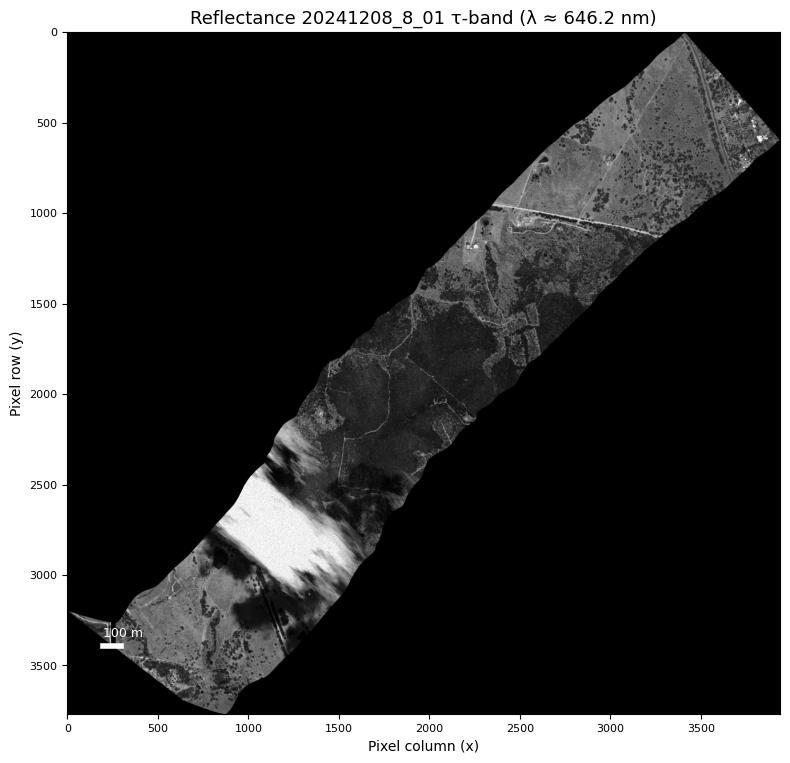

✅ Displayed cropped τ-band region → row0=None, col0=None, size=(None, None)


In [189]:


# ===============================================================
#  Plot  image a quick image of the τ band with scale bar
# ===============================================================
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(refl_norm, cmap='gray', origin='upper')
ax.set_title(f"Reflectance {target_image_id} τ-band (λ ≈ {wavelengths[tau_band_indices[0]]:.1f} nm)", fontsize=13)

# Show pixel coordinate ticks
ax.set_xlabel("Pixel column (x)")
ax.set_ylabel("Pixel row (y)")
ax.tick_params(labelsize=8)
ax.grid(False)

# Add scale bar (100 m)
px_size = float(img_refl.metadata['map info'][5])  # pixel size in m
bar_length_m = 100
bar_length_px = bar_length_m / px_size
x0 = band_refl_crop.shape[1] * 0.05
y0 = band_refl_crop.shape[0] * 0.9
ax.plot([x0, x0 + bar_length_px], [y0, y0], 'w-', lw=4)
ax.text(x0, y0 - 30, f'{bar_length_m:.0f} m', color='white', fontsize=9, va='bottom')

plt.tight_layout()
plt.show()

print(f"✅ Displayed cropped τ-band region → row0={row0}, col0={col0}, size=({n_rows}, {n_cols})")


In [190]:
# --- Base directories ---
lrt_relative_prefix = "../data/filter/mjolnir/converted/"
default_albedo = 0.015        # for τ / rₑ retrieval
albedo_o2 = 0.015            # for O₂ absorption (radiance mode)

# --- Function to read band files and produce input for libradtran ---
def make_bdata(band_indices, albedo_value, label=""):
    bdata_list = []
    for band_index in band_indices:
        band_num = band_index + 1  # rsp files are 1-based
        filename = f"band{band_num:03d}.rsp"
        filter_file_abs = os.path.join(filter_dir, filename)

        if not os.path.exists(filter_file_abs):
            print(f"⚠️ Missing filter file for {label}: {filter_file_abs}")
            continue

        try:
            # ✅ Load RSP data (skip header)
            data = np.loadtxt(filter_file_abs, skiprows=1)
            wl = np.array(data[:, 0], dtype=float)

            # Convert µm → nm if needed
            if np.max(wl) < 100:
                wl *= 1000.0

            wl_min = int(np.ceil(np.min(wl)))
            wl_max = int(np.floor(np.max(wl)))
            wl_range = f"{wl_min} {wl_max}"

            # Relative path for libRadtran
            filter_file_rel = os.path.join(lrt_relative_prefix, filename)

            # Append entry
            bdata_list.append([wl_range, filter_file_rel, f"{albedo_value:.3f}"])

        except Exception as e:
            print(f"⚠️ Could not read {filter_file_abs}: {e}")
            continue
    return bdata_list


# --- Build separate lists ---
bdata_o2 = make_bdata(o2_off_band_indices + o2_on_band_indices, albedo_o2, label="O₂")
bdata_tau_re = make_bdata(tau_band_indices + re_band_indices, default_albedo, label="τ/rₑ")

# --- Summaries ---
print("\n✅ Generated O₂ band data (radiance retrieval):")
for entry in bdata_o2:
    print("   ", entry)

print("\n✅ Generated τ/rₑ band data (reflectance retrieval):")
for entry in bdata_tau_re:
    print("   ", entry)


✅ Generated O₂ band data (radiance retrieval):
    ['739 752', '../data/filter/mjolnir/converted/band116.rsp', '0.015']
    ['744 757', '../data/filter/mjolnir/converted/band118.rsp', '0.015']
    ['747 760', '../data/filter/mjolnir/converted/band119.rsp', '0.015']
    ['750 763', '../data/filter/mjolnir/converted/band120.rsp', '0.015']
    ['753 766', '../data/filter/mjolnir/converted/band121.rsp', '0.015']
    ['756 769', '../data/filter/mjolnir/converted/band122.rsp', '0.015']
    ['759 772', '../data/filter/mjolnir/converted/band123.rsp', '0.015']

✅ Generated τ/rₑ band data (reflectance retrieval):
    ['640 653', '../data/filter/mjolnir/converted/band082.rsp', '0.015']
    ['2125 2148', '../data/filter/mjolnir/converted/band416.rsp', '0.015']


In [191]:
### This function sets up the basic settings for the radiative transfer model
def create_rtm_clear(bdata, surface_alt_km=0.0, sensor_zout_km=0.0, solar_zen=0.0, solar_azimuth=0.0):
    """
    Create a libRadtran radiative transfer model for clear-sky O2 A-band calculation.
    """
    lrt = RadTran(LIBRADTRAN_FOLDER)

    lrt.options['rte_solver'] = 'disort'
    lrt.options['source'] = 'solar ../data/solar_flux/kurudz_0.1nm.dat per_nm'
    #lrt.options['atmosphere_file'] = 'tropics'# define atmosphere by keyword
    lrt.options['atmosphere_file'] = '../data/atmmod/afglt.dat'  #standard tropical atmosphere
    lrt.options['wavelength'] = bdata[0]
    lrt.options['filter_function_file'] = bdata[1]
    lrt.options['mol_abs_param'] = 'reptran fine'
    #lrt.options['mol_modify h2o'] = '0 mm'  # This line sets the h2o concetration to 0, it 
    lrt.options['output_user'] = 'uu' #calculate radiances
    lrt.options['output_quantity'] = 'reflectivity'  # options are reflectivity/brightness/transmittance
    #lrt.options['albedo_library'] =  'IGBP',  #This isn't working here, but should select an internal library of albedo functions, it works in my fogging script  
    #lrt.options['brdf_rpv_type'] = "17", ##  #This isn't working here, but it selects ocean water from the library 
    lrt.options['albedo'] = bdata[2] # this selects a number from the 'bdata' array to use as albedo
    lrt.options['sza'] = str(solar_zen)   #solar zenith angle taken from flight metadata. 
    lrt.options['phi0'] = str(solar_azimuth)   #this is not important, but here for completeness
    lrt.options['phi'] = '0'
    lrt.options['umu'] = '1.0' #looking down
    lrt.options['altitude'] = str(surface_alt_km)  # This is where the surface heights is set. 
    lrt.options['zout'] = str(sensor_zout_km)
    lrt.options['output_process'] = 'integrate'

    return lrt

### this function calls the RT functions and runs the calculations with the settings for each image that are likely to change regularly

def run_o2_lut_clear(banddata, on_bands, off_bands, flight_alt_m, solar_zen, solar_azimuth, nsteps=50):
    """
    Run clear-sky O2 A-band reflectance vs. surface height at a fixed sensor altitude.

    Parameters
    ----------
    banddata : list
        [[wavelength_range, filter_file, albedo], ...]
    on_bands : list of str
        On-band identifiers, e.g. ['band121', 'band122', 'band123']
    off_bands : list of str
        Off-band identifiers, e.g. ['band117', 'band118', 'band119', 'band120']
    flight_alt_m : float
        Sensor altitude (m above sea level)
    solar_zen, solar_azimuth : float
        Sun geometry (degrees)
    nsteps : int
        Number of surface height steps between 0 and flight altitude
    """
    flight_alt_km = flight_alt_m / 1000.0
    surface_heights_km = np.linspace(0.0, flight_alt_km, nsteps)  # surface height profile

    records = []

    for surf_h in surface_heights_km:
        # Fixed sensor altitude above sea level
        sensor_zout_km = flight_alt_km

        entry = {'surface_alt_km': surf_h, 'sensor_zout_km': sensor_zout_km}

        # Run RTM for each band
        for band in banddata:
            rtm = create_rtm_clear(
                band,
                surface_alt_km=surf_h,
                sensor_zout_km=sensor_zout_km,
                solar_zen=solar_zen,
                solar_azimuth=solar_azimuth
            )
            refl = rtm.run().mean()
            band_name = os.path.splitext(os.path.basename(band[1]))[0]  # e.g. band121
            entry[f'refl_{band_name}'] = refl

        records.append(entry)

    df = pd.DataFrame(records)

    # --- compute mean(on/off) and ratio ---
    on_cols = [f'refl_{b}' for b in on_bands]
    off_cols = [f'refl_{b}' for b in off_bands]
    df['mean_on'] = df[on_cols].mean(axis=1)
    df['mean_off'] = df[off_cols].mean(axis=1)
    df['ratio_on_off'] = df['mean_on'] / df['mean_off']

    outcsv = f"output/o2_clear_profile_{nsteps}steps.csv"
    df.to_csv(outcsv, index=False)
    print(f"Saved O2 clear-sky LUT → {outcsv}")

    return df


In [192]:
## In here we run the calculation. 

## to get fog plume top try same number of steps but from 200m above surface, rather than from flight alt

#alt = 200 #comment this line out if you want to use the actual flight altitude from metadata

alt_steps = 20

# --- Construct lists of O₂ band filenames (based on current indices) ---
on_band_files  = [f"band{(i+1):03d}" for i in o2_on_band_indices]   # +1 because RSP files are 1-based
off_band_files = [f"band{(i+1):03d}" for i in o2_off_band_indices]

print("Off-band files:", off_band_files)
print("On-band files: ", on_band_files)

# --- Get libradtran folder  ---
LIBRADTRAN_FOLDER = get_lrt_folder()

# --- Run O₂ LUT calculation using clear-sky configuration ---
df_o2 = run_o2_lut_clear(
    banddata=bdata_o2,                 # ✅ now using O₂-specific band list
    on_bands=on_band_files,
    off_bands=off_band_files,
    flight_alt_m=float(alt),
    solar_zen=float(solar_zen),
    solar_azimuth=float(solar_azi),
    nsteps=alt_steps
)

print("\n✅ O₂ LUT generated successfully:")

Off-band files: ['band116', 'band118', 'band119', 'band120']
On-band files:  ['band121', 'band122', 'band123']
Saved O2 clear-sky LUT → output/o2_clear_profile_20steps.csv

✅ O₂ LUT generated successfully:


In [193]:
df_o2

,surface_alt_km,sensor_zout_km,refl_band116,refl_band118,refl_band119,refl_band120,refl_band121,refl_band122,refl_band123,mean_on,mean_off,ratio_on_off
0,0.000000,2.321472,0.017018,0.017087,0.017063,0.016705,0.010714,0.007741,0.011681,0.010045,0.016968,0.592005
1,0.122183,2.321472,0.017000,0.017062,0.017039,0.016684,0.010747,0.007809,0.011730,0.010095,0.016946,0.595717
2,0.244365,2.321472,0.016984,0.017039,0.017015,0.016665,0.010781,0.007877,0.011778,0.010145,0.016926,0.599395
3,0.366548,2.321472,0.016968,0.017017,0.016993,0.016647,0.010815,0.007944,0.011826,0.010195,0.016906,0.603038
4,0.488731,2.321472,0.016953,0.016997,0.016973,0.016630,0.010850,0.008012,0.011874,0.010245,0.016888,0.606645
5,0.610914,2.321472,0.016940,0.016978,0.016954,0.016614,0.010885,0.008079,0.011921,0.010295,0.016871,0.610213
6,0.733096,2.321472,0.016923,0.016955,0.016932,0.016596,0.010920,0.008147,0.011968,0.010345,0.016851,0.613883
7,0.855279,2.321472,0.016901,0.016929,0.016905,0.016573,0.010954,0.008215,0.012013,0.010394,0.016827,0.617699
8,0.977462,2.321472,0.016881,0.016904,0.016880,0.016552,0.010988,0.008284,0.012059,0.010443,0.016804,0.621483
9,1.099645,2.321472,0.016862,0.016880,0.016856,0.016532,0.011023,0.008352,0.012104,0.010493,0.016782,0.625240


In [194]:
### This is a function to plot the images for the oxygen surface height retrival in python

def plot_ratio_image(
        img,
        base_name="",
        vmin=None,
        vmax=None,
        cbar_label="Value",
        cmap="viridis",
        percentile=(2, 98),
        rotate_if_portrait=True,
        figsize_scale=12
):
    """
    Generic fast image plotter with auto-orientation and percentile scaling.

    Parameters
    ----------
    img : 2D numpy array or masked array
        Image to display.
    base_name : str
        Title text.
    vmin, vmax : float or None
        Manual scaling. If None, will use percentile stretch.
    cbar_label : str
        Label for the colorbar.
    cmap : str or Colormap
        Colormap to use.
    percentile : (low, high)
        Percentile stretch for autoscaling (default 2–98).
    rotate_if_portrait : bool
        Rotate if aspect < 1.
    figsize_scale : float
        Controls how large the figure is.
    """

    img = np.ma.array(img)

    h, w = img.shape
    aspect = w / h

    # Auto-rotate portrait images
    if rotate_if_portrait and aspect < 1:
        img_plot = np.rot90(img, k=1)
        orientation = "rotated"
        h2, w2 = img_plot.shape
    else:
        img_plot = img
        orientation = "normal"
        h2, w2 = h, w

    # Auto figure size proportional to aspect
    if w2 > h2:
        fig_w = figsize_scale
        fig_h = figsize_scale * (h2 / w2)
    else:
        fig_h = figsize_scale
        fig_w = figsize_scale * (w2 / h2)

    # Percentile stretch (unless vmin/vmax provided)
    if vmin is None or vmax is None:
        finite_data = img_plot.compressed()
        if finite_data.size > 0:
            p_low, p_high = percentile
            vmin, vmax = np.percentile(finite_data, [p_low, p_high])
        else:
            vmin, vmax = 0, 1

    # Plot
    plt.figure(figsize=(fig_w, fig_h))

    cmap_obj = plt.matplotlib.colormaps[cmap].copy()
    cmap_obj.set_bad(color="white")

    im = plt.imshow(img_plot, cmap=cmap_obj, vmin=vmin, vmax=vmax)
    plt.axis("off")

    cbar = plt.colorbar(im, fraction=0.03, pad=0.02)
    cbar.set_label(cbar_label, fontsize=12)

    plt.title(f"{base_name} [{orientation}]", fontsize=14)
    plt.tight_layout()
    plt.show()

In [195]:
### This opens the selected wavelength bands of the image and creats a ratio image of the on/off absorptions
#It masks values off the image first
img = spy.envi.open(rad_hdr_path, rad_path)
img_metadata = img.metadata
wavelengths = np.array([float(w) for w in img_metadata.get("wavelength", [])])

def find_band(target_nm):
    return int(np.argmin(np.abs(wavelengths - target_nm)))

off_band_indices = [find_band(w) for w in o2_off_wl_targets]
on_band_indices  = [find_band(w) for w in o2_on_wl_targets]

print("Off-band indices:", off_band_indices,
      "→ wavelengths:", wavelengths[off_band_indices])

print("On-band indices:", on_band_indices,
      "→ wavelengths:", wavelengths[on_band_indices])
band_images = {}

for b in off_band_indices + on_band_indices:
    band_images[b] = img.read_band(b)
# --- 1. Build stacks for averaging ---
off_stack = np.stack([band_images[i] for i in off_band_indices])
on_stack  = np.stack([band_images[i] for i in on_band_indices])

# --- 2. Compute averages ---
off_avg_raw = np.nanmean(off_stack, axis=0)
on_avg_raw  = np.nanmean(on_stack, axis=0)

# --- 3. Valid data mask ---
valid_mask = (
        (off_avg_raw > 0) &
        (on_avg_raw > 0) &
        (~np.isnan(off_avg_raw)) &
        (~np.isnan(on_avg_raw))
)

# --- 4. Make masked arrays ---
off_avg = np.ma.array(off_avg_raw, mask=~valid_mask)
on_avg  = np.ma.array(on_avg_raw,  mask=~valid_mask)

# --- 5. Ratio on/off ---
ratio = np.ma.divide(on_avg, off_avg)

# --- 6. Final masked ratio ---
ratio_masked = np.ma.masked_invalid(ratio)
ratio_masked = np.ma.masked_where(ratio_masked <= 0, ratio_masked)

# Now ratio_masked is ready to pass to the plotting function.


Off-band indices: [115, 117, 118, 119] → wavelengths: [745.06266 750.87719 753.78446 756.69173]
On-band indices: [120, 121, 122] → wavelengths: [759.599   762.50627 765.41353]


/home/danlab/.virtualenvs/python_LRT/lib/python3.12/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


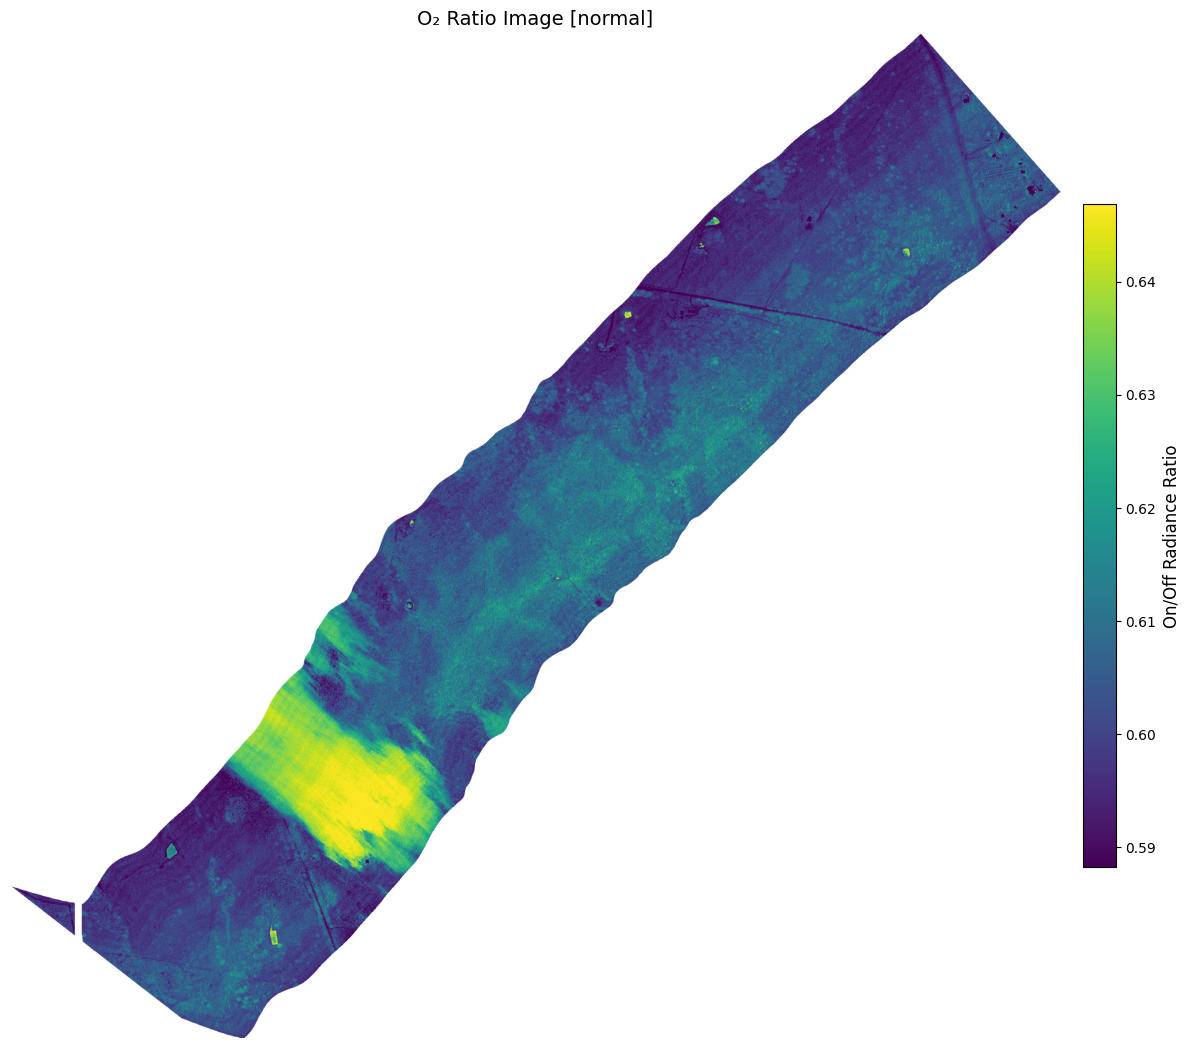

In [196]:

#use the plot function to plot the ratio image
plot_ratio_image(
    ratio_masked,
    base_name="O₂ Ratio Image",
    cbar_label="On/Off Radiance Ratio",
    cmap="viridis",
    percentile=(1, 99)
)

In [197]:
ratio_lut = df_o2["ratio_on_off"].values
surface_km = df_o2["surface_alt_km"].values
# ---- 1. Create cubic monotonic interpolator (no extrapolation) ----
lut_interp = PchipInterpolator(
    ratio_lut,
    surface_km,
    extrapolate=False   # <-- Important: no extrapolation
)

# ---- 2. Evaluate only where ratio is valid ----
ratio_data = ratio_masked.data
min_lut = ratio_lut.min()
max_lut = ratio_lut.max()


# Flatten the ratio data (masked array)
ratio_data_flat = ratio_masked.data.ravel()
ratio_mask = ratio_masked.mask.ravel()

# Consider only valid pixels
valid_ratio = ratio_data_flat[~ratio_mask]

# Count out-of-range values
out_of_range = (valid_ratio < min_lut) | (valid_ratio > max_lut)
num_oor = np.sum(out_of_range)
num_valid = valid_ratio.size

if num_valid > 0:
    pct_oor = 100 * num_oor / num_valid
else:
    pct_oor = 0

if num_oor > 0:
    print(f"⚠ Warning: {pct_oor:.2f}% of valid pixels "
          f"({num_oor:,d} / {num_valid:,d}) are outside LUT range "
          f"({min_lut:.4f}–{max_lut:.4f}) and will be set to NaN.")
interp_values = lut_interp(ratio_data)

# Pchip returns "np.nan" for values outside range if extrapolate=False
surface_img = np.ma.array(interp_values, mask=ratio_masked.mask | np.isnan(interp_values))

⚠ Warning: 4.29% of valid pixels (152,439 / 3,553,735) are outside LUT range (0.5920–0.6621) and will be set to NaN.


## Out of range pixles
Some images have low and high pixels out of range of the look up table, it is unclear why
Adding buffer altitude to the calculation should work,but it is artifical. Why should the surface be higher than the aircraft or lower than sealevel
It probably hints at errors in the calculation

I looked up 26022024-1_24, there are high level clouds. This could be a big cause of error in the calculations.
I think libradtran lets you scale the inbound radiation

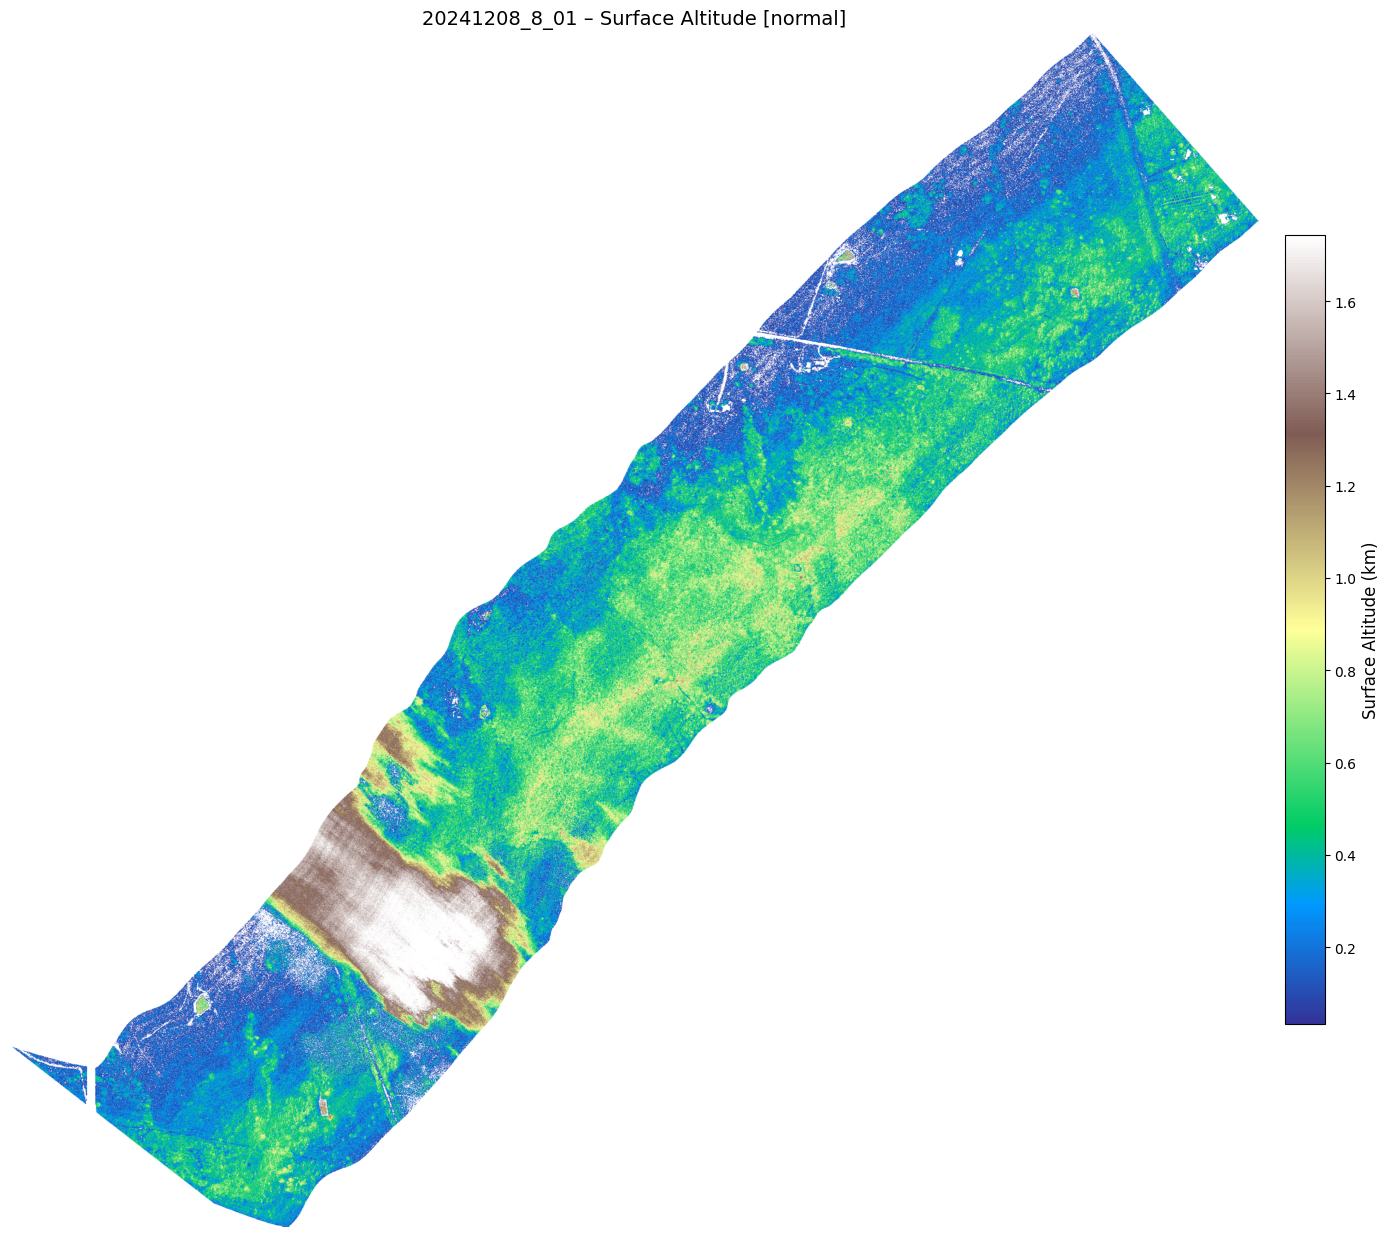

In [198]:
plot_ratio_image(
    surface_img,
    base_name=f"{imageID} – Surface Altitude",
    cbar_label="Surface Altitude (km)",
    cmap="terrain",
    percentile=(2, 98),
    figsize_scale=14
)


## This next code makes a set of discrete levels of clouds
 This is done so that one, or multiple CTH/CTT can be used for the next section and the next LUT is not calculated pixel by pixel


/home/danlab/.virtualenvs/python_LRT/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


CTH levels (km) for LUT: [0.347 0.442 0.55  0.999 1.587]


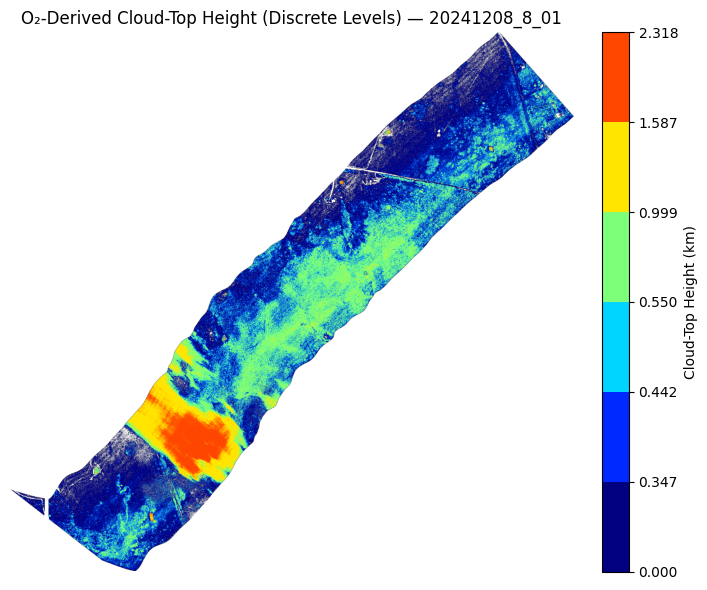

In [213]:
## This bit makes a set of discrete levels of clouds, so that one, or multiple CTH/CTT can be used for the next section
#
# make a simple cloud mask: (tune thresholds)
cth_km = surface_img  # rename for clarity
cloud_mask = np.isfinite(cth_km) & (cth_km > 0.3)  # e.g., >300 m above “surface/sea”
if np.count_nonzero(cloud_mask) == 0:
    raise ValueError("No cloudy pixels found by the O2-based mask. Check thresholds.")

# summarize CTH for LUT building: choose a few quantiles
cth_values_km = cth_km[cloud_mask]
cth_levels_km = np.unique(np.round(np.quantile(cth_values_km, [0.1, 0.3, 0.5, 0.85, 0.94]), 3))
print("CTH levels (km) for LUT:", cth_levels_km)

# Define bins for discrete levels
bins = np.concatenate(([cth_km[np.isfinite(cth_km)].min()],
                       cth_levels_km,
                       [cth_km[np.isfinite(cth_km)].max()]))

# Create a discrete colormap (you can choose 'jet', 'viridis', or custom)
n_colors = len(bins) - 1
cmap = plt.cm.jet
discrete_cmap = mcolors.ListedColormap([cmap(i / n_colors) for i in range(n_colors)])

# Normalize using boundaries
norm = mcolors.BoundaryNorm(bins, discrete_cmap.N)

# --- Plot ---
plt.figure(figsize=(8, 6))
im = plt.imshow(cth_km, cmap=discrete_cmap, norm=norm)
plt.colorbar(im, fraction=0.046, pad=0.04, label='Cloud-Top Height (km)')
plt.title(f'O₂-Derived Cloud-Top Height (Discrete Levels) — {base_name}')
plt.axis('off')
plt.tight_layout()
plt.show()

In [214]:
cth_levels_km

masked_array(data=[0.347, 0.442, 0.55 , 0.999, 1.587],
             mask=False,
       fill_value=1e+20)

Upper cloud threshold: 0.999 km
Pixels above threshold: 345123


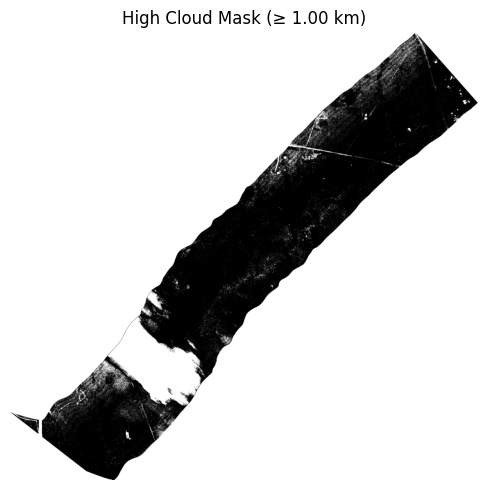

In [215]:
# ===============================================================
# Select only the upper two quantile levels
# ===============================================================
high_cloud_threshold = cth_levels_km[-2]  # 85th percentile
upper_cloud_mask = cth_km >= high_cloud_threshold

print(f"Upper cloud threshold: {high_cloud_threshold:.3f} km")
print(f"Pixels above threshold: {np.count_nonzero(upper_cloud_mask)}")


# --- Plot high-cloud mask for verification ---
plt.figure(figsize=(6, 5))
plt.imshow(upper_cloud_mask, cmap='gray')
plt.title(f'High Cloud Mask (≥ {high_cloud_threshold:.2f} km)')
plt.axis('off')
plt.tight_layout()
plt.show()

# Cloud physics section

In [200]:
# ===============================================================
# ☁️  LUT FOR CLOUD PHYSICS CONFIGURATION —  SETTINGS
# ===============================================================

# --- Cloud-top height selection (choose quantile or set manually) ---
selected_cth_km = float(np.nanmax(cth_levels_km))   # Select the upper quantile CTH from above image
#selected_cth_km = 0.325                            # ← manual override if needed
cth_levels_km = [selected_cth_km]  # sets an array

# --- Cloud & surface properties ---
cloud_thickness = 200   # [m] assumed geometric thickness of cloud
#cloud_temp = 300        # [K] (will be overwritten by lapse rate)
lapse_rate = 6.5        # [K/km]
T0_surface = 25 + 273.15 # [K] surface reference temperature

# --- libRadtran installation ---
LIBRADTRAN_FOLDER = get_lrt_folder()

# --- Geometry and flight parameters ---
solar_zenith  = float(solar_zen)
solar_azimuth = float(solar_azi)
altitude_km   = float(alt) / 1000.0  # m → km

# --- Lookup-table parameter grid ---
vals = {
    're':   np.array([2.5, 3, 4, 6, 8, 12, 16, 20, 26, 32, 50]),   # Effective radius [µm]
    'tau':  np.array([1, 2, 4, 6, 8, 10, 16, 32, 56, 64]),         # Optical thickness
    'solz': np.array([solar_zenith]),                               # solar zenith from flight data
    'satz': np.array([np.cos(np.deg2rad(0.0))]),                    # viewing zenith (nadir)
    'raz':  np.array([0.0])                                         # relative azimuth (nadir)
}

# --- Band data (from RSP parsing step) ---
banddata = bdata_tau_re   # ensure τ/re bands only

print("\n✅ libRadtran configuration ready:")
print(f"• Solar zenith:   {solar_zenith:.2f}°")
print(f"• Solar azimuth:  {solar_azimuth:.2f}°")
print(f"• Altitude:       {altitude_km:.3f} km")
print(f"• Cloud-top height: {selected_cth_km:.3f} km")
print(f"• Bands defined:  {len(banddata)}")
for entry in banddata:
    print("  ", entry)


# ===============================================================
# 🧩 LIBRADTRAN SETUP FUNCTIONS
# ===============================================================

def create_rtm(bdata, LIBRADTRAN_FOLDER, altitude_km, solar_azimuth, vals):
    """Set up a libRadtran RTM for one wavelength band (multiprocessing-safe)."""
    lrt = RadTran(LIBRADTRAN_FOLDER)
    lrt.options['rte_solver'] = 'disort'
    lrt.options['source'] = 'solar ../data/solar_flux/kurudz_0.1nm.dat per_nm'
    lrt.options['atmosphere_file'] = '../data/atmmod/afglt.dat'  #standard tropical atmosphere
    lrt.options['wavelength'] = bdata[0]
    lrt.options['filter_function_file'] = bdata[1]
    lrt.options['mol_modify h2o'] = '0 mm'
    lrt.options['output_user'] = 'uu'
    lrt.options['output_quantity'] = 'reflectivity'
    lrt.options['zout'] = altitude_km
    lrt.options['albedo'] = bdata[2]
    lrt.options['umu'] = ' '.join([str(a)[:5] for a in vals['satz']])
    lrt.options['phi'] = ' '.join([str(a) for a in vals['raz']])
    lrt.options['phi0'] = str(solar_azimuth)
    lrt.options['output_process'] = 'integrate'
    return lrt


def get_refl_cth(inputs):
    """Run RTM for a single combination of parameters."""
    (bands, re, tau, solz, cloud, totalind, cth_km,
     cloud_temp, LIBRADTRAN_FOLDER, altitude_km, solar_azimuth, vals) = inputs

    out = {'re': re, 'tau': tau, 'solz': solz, 'cth_km': cth_km, 'cloud_temp': cloud_temp}

    for band in bands:
        rtm = create_rtm(band, LIBRADTRAN_FOLDER, altitude_km, solar_azimuth, vals)
        rtm.cloud = cloud
        rtm.options['sza'] = str(solz)
        refl = rtm.run()
        band_name = os.path.splitext(os.path.basename(band[1]))[0]
        out[f'refl_{band_name}'] = np.mean(refl)

    out['index'] = totalind
    return out


# ===============================================================
# ⚙️ MAIN LUT BUILDER
# ===============================================================

def build_lut_with_cth(banddata, vals, cth_levels_km, cloud_thickness_m,
                       LIBRADTRAN_FOLDER, altitude_km, solar_azimuth):
    """Build LUT over (re, tau, solz) for each cloud-top height with lapse-rate temperature."""
    dz = cloud_thickness_m
    f_ad = 1
    rho_w = 1e6
    const_A = 2/3 * rho_w * f_ad * 1e-6

    tasks = []
    totalind = 0

    for cth_km in cth_levels_km:
        cloud_temp = T0_surface - lapse_rate * cth_km
        for re in vals['re']:
            for tau in vals['tau']:
                lwc = const_A * tau * re / dz
                if ((re > 600) or (re < 0.2)) and (lwc > 0):
                    continue

                z_top = float(cth_km)
                z_base = max(0.0, z_top - (dz / 1000.0))
                cloud = {'z': [z_top, z_base],
                         'lwc': [0.0, lwc],
                         're': [re, re],
                         'T': [cloud_temp, cloud_temp]}

                for solz in vals['solz']:
                    totalind += 1
                    tasks.append([
                        banddata, re, tau, solz, cloud, totalind,
                        cth_km, cloud_temp,
                        LIBRADTRAN_FOLDER, altitude_km, solar_azimuth, vals
                    ])

    # Parallel computation
    with Pool(8) as pool:
        results = pool.map(get_refl_cth, tasks)

    # Convert to DataFrame and save
    df = pd.DataFrame(results).sort_values(['cth_km', 're', 'tau'], ignore_index=True)
    tag = f"cth{len(cth_levels_km)}_{cth_levels_km[0]:.3f}km"
    fnamecsv = f"output/lut_{tag}_re{len(vals['re'])}_tau{len(vals['tau'])}_bands{len(banddata)}.csv"
    df.to_csv(fnamecsv, index=False)
    df.to_pickle(fnamecsv.replace('.csv', '.pkl'))
    print(f"✅ Saved LUT with lapse-rate-adjusted T: {fnamecsv}")
    return df




✅ libRadtran configuration ready:
• Solar zenith:   9.18°
• Solar azimuth:  85.02°
• Altitude:       2.321 km
• Cloud-top height: 1.587 km
• Bands defined:  2
   ['640 653', '../data/filter/mjolnir/converted/band082.rsp', '0.015']
   ['2125 2148', '../data/filter/mjolnir/converted/band416.rsp', '0.015']


In [201]:
# Run Cloud calculation
lut = build_lut_with_cth(
    banddata=banddata,
    vals=vals,
    cth_levels_km=cth_levels_km,
    cloud_thickness_m=cloud_thickness,
    LIBRADTRAN_FOLDER=LIBRADTRAN_FOLDER,
    altitude_km=altitude_km,
    solar_azimuth=solar_azimuth
)

✅ Saved LUT with lapse-rate-adjusted T: output/lut_cth1_1.587km_re11_tau10_bands2.csv


Plotting LUT for SZA=9.18°, CTH=1.587 km


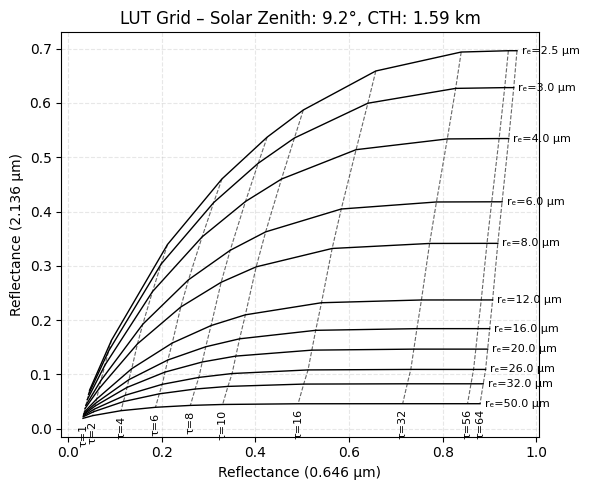

In [202]:
solz_target = float(solar_zen)

# Make sure your LUT DataFrame is called df_lut
#lut = df_lut.copy()

# Filter for matching solar zenith (and single CTH if present)
plotdata = lut[np.isclose(lut['solz'], solz_target)]
if 'cth_km' in plotdata.columns:
    cth_target = plotdata['cth_km'].unique()[0]
    plotdata = plotdata[plotdata['cth_km'] == cth_target]
else:
    cth_target = None

if plotdata.empty:
    raise ValueError(f"No LUT entries found for solar zenith = {solz_target:.2f}°")

print(f"Plotting LUT for SZA={solz_target:.2f}°, CTH={cth_target if cth_target else 'N/A'} km")

# ===============================================================
#  🧭 Band mapping and labels
# ===============================================================
# Get reflectance columns
band_cols = sorted([col for col in lut.columns if col.startswith("refl_band")])
if len(band_cols) < 2:
    raise ValueError(f"Expected at least 2 refl_band columns, found {len(band_cols)}: {band_cols}")

# Generate readable band labels from bdata
band_labels = []
for b in bdata_tau_re:
    wl_min, wl_max = map(float, b[0].split())
    wl_mid = 0.5 * (wl_min + wl_max)
    band_labels.append(f"{wl_mid/1000:.3f} µm")

# Map index to label (optional use later)
band_map = {band_cols[i]: band_labels[i] for i in range(len(band_labels))}

# Pick axes (shortest vs longest wavelength)
xcol, ycol = band_cols[0], band_cols[-1]

# ===============================================================
#  🖼️ Plot reflectance grid
# ===============================================================
fig, ax = plt.subplots(figsize=(6, 5))

re_vals = sorted(plotdata['re'].unique())
tau_vals = sorted(plotdata['tau'].unique())

# --- Effective radius grid (solid lines) ---
for re in re_vals:
    subset = plotdata[plotdata['re'] == re]
    ax.plot(subset[xcol], subset[ycol], 'k-', lw=1)
    ax.text(subset[xcol].iloc[-1] + 0.01,
            subset[ycol].iloc[-1],
            f"rₑ={re:.1f} µm", va='center', fontsize=8)

# --- Optical thickness grid (dashed lines) ---
for tau in tau_vals:
    subset = plotdata[plotdata['tau'] == tau]
    ax.plot(subset[xcol], subset[ycol], 'k--', lw=0.8, alpha=0.6)
    ax.text(subset[xcol].iloc[-1],
            subset[ycol].iloc[-1] - 0.01,
            f"τ={tau}", ha='center', va='top', rotation=90, fontsize=8)

# --- Labels and styling ---
ax.set_xlabel(f"Reflectance ({band_map[xcol]})")
ax.set_ylabel(f"Reflectance ({band_map[ycol]})")
ax.grid(True, which='both', linestyle='--', alpha=0.3)
title = f"LUT Grid – Solar Zenith: {solz_target:.1f}°"
if cth_target:
    title += f", CTH: {cth_target:.2f} km"
plt.title(title)
plt.tight_layout()
plt.show()

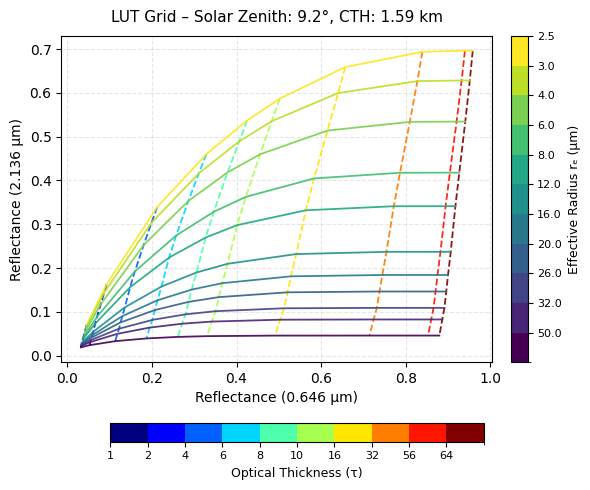

In [203]:

fig, ax = plt.subplots(figsize=(6, 5))

re_vals = sorted(plotdata['re'].unique())
tau_vals = sorted(plotdata['tau'].unique())

# --- Your chosen colormaps ---
cmap_tau = plt.cm.jet
cmap_re  = plt.cm.viridis_r

# --- Create discrete color lists ---
tau_colors = [cmap_tau(i / (len(tau_vals) - 1)) for i in range(len(tau_vals))]
re_colors  = [cmap_re(i / (len(re_vals) - 1))  for i in range(len(re_vals))]

# --- Plot τ (optical thickness) lines (dashed) ---
for tau, color in zip(tau_vals, tau_colors):
    subset = plotdata[plotdata['tau'] == tau]
    ax.plot(subset[xcol], subset[ycol],
            color=color, ls='--', lw=1.3, alpha=0.9, label=f'τ={tau}')

# --- Plot rₑ (effective radius) lines (solid) ---
for re, color in zip(re_vals, re_colors):
    subset = plotdata[plotdata['re'] == re]
    ax.plot(subset[xcol], subset[ycol],
            color=color, ls='-', lw=1.3, alpha=0.9, label=f'rₑ={re:.0f} µm')

# --- Axis labels and grid ---
ax.set_xlabel(f"Reflectance ({band_map[xcol]})", fontsize=10)
ax.set_ylabel(f"Reflectance ({band_map[ycol]})", fontsize=10)
ax.grid(True, which='both', linestyle='--', alpha=0.3)

# --- Title ---
title = f"LUT Grid – Solar Zenith: {solz_target:.1f}°"
if cth_target:
    title += f", CTH: {cth_target:.2f} km"
ax.set_title(title, fontsize=11, pad=10)

# ===============================================================
# 🎨 Discrete colorbars
# ===============================================================

# τ colorbar – bottom
norm_tau = mcolors.BoundaryNorm(tau_vals + [tau_vals[-1] + 1], cmap_tau.N)
sm_tau = cm.ScalarMappable(norm=norm_tau, cmap=cmap_tau)
cbar_tau = fig.colorbar(sm_tau, ax=ax, orientation='horizontal',
                        pad=0.15, fraction=0.046, ticks=tau_vals)
cbar_tau.set_label('Optical Thickness (τ)', fontsize=9)
cbar_tau.ax.tick_params(labelsize=8)

# rₑ colorbar – right
norm_re = mcolors.BoundaryNorm(re_vals + [re_vals[-1] + 1], cmap_re.N)
sm_re = cm.ScalarMappable(norm=norm_re, cmap=cmap_re)
cbar_re = fig.colorbar(sm_re, ax=ax, orientation='vertical',
                       pad=0.04, fraction=0.046, ticks=re_vals)

# Reverse the colorbar direction so it matches plotted lines
cbar_re.ax.invert_yaxis()

cbar_re.set_label('Effective Radius rₑ (µm)', fontsize=9)
cbar_re.ax.tick_params(labelsize=8)

# ===============================================================
plt.tight_layout()
plt.show()

In [204]:
### Another plotting function, probably don't need two
def plot_image(
        img2d,
        base_name="",
        vmin=None,
        vmax=None,
        cbar_label="Value",
        cmap="viridis",
        mask_threshold=None,
        percentile_stretch=(2, 98)
):
    """
    Fast, auto-oriented 2D image plotter with percentile autoscaling 
    and optional background masking.

    Parameters
    ----------
    img2d : 2D numpy array
        Image to display.
    base_name : str
        Title prefix.
    vmin, vmax : float or None
        Manual scaling. If None, autoscale using percentile_stretch.
    cbar_label : str
        Label for the colorbar.
    cmap : str or Colormap
        Colormap.
    mask_threshold : float or None
        If provided, all values <= mask_threshold become NaN.
    percentile_stretch : (low, high)
        Percentile range for autoscaling (default 2–98%).
    """

    img = img2d.astype(float).copy()

    # --------------------------------------------------------------
    # 1. Mask background
    # --------------------------------------------------------------
    if mask_threshold is not None:
        img[img <= mask_threshold] = np.nan

    # --------------------------------------------------------------
    # 2. Rotate if portrait
    # --------------------------------------------------------------
    h, w = img.shape
    aspect = w / h

    if aspect < 1:
        img_plot = np.rot90(img, k=1)
        orientation = "rotated"
        h2, w2 = img_plot.shape
    else:
        img_plot = img
        orientation = "normal"
        h2, w2 = h, w

    # --------------------------------------------------------------
    # 3. Auto figure size
    # --------------------------------------------------------------
    if w2 > h2:
        fig_w = 12
        fig_h = 12 * (h2 / w2)
    else:
        fig_h = 12
        fig_w = 12 * (w2 / h2)

    # --------------------------------------------------------------
    # 4. Percentile stretch (unless vmin/vmax already provided)
    # --------------------------------------------------------------
    finite_vals = img_plot[np.isfinite(img_plot)]

    if (vmin is None) or (vmax is None):
        if finite_vals.size > 0:
            low, high = percentile_stretch
            vmin, vmax = np.nanpercentile(finite_vals, [low, high])
        else:
            vmin, vmax = 0, 1

    # --------------------------------------------------------------
    # 5. Plot
    # --------------------------------------------------------------
    plt.figure(figsize=(fig_w, fig_h))

    cmap_obj = plt.matplotlib.colormaps[cmap].copy()
    cmap_obj.set_bad(color="white")  # masked areas

    im = plt.imshow(img_plot, cmap=cmap_obj, vmin=vmin, vmax=vmax)
    plt.axis("off")

    cbar = plt.colorbar(im, fraction=0.03, pad=0.02)
    cbar.set_label(cbar_label, fontsize=12)

    plt.title(f"{base_name} ]", fontsize=14)
    plt.tight_layout()
    plt.show()


In [205]:

def find_band(target_nm):
    """Return index of wavelength closest to target (0-based for ENVI read)."""
    return int(np.argmin(np.abs(wavelengths - target_nm))+1)

# 2. Get ENVI band indices (0-based)
band_tau = find_band(tau_wl_targets[0])
band_re  = find_band(re_wl_targets[0])

print("τ-band:", tau_wl_targets[0], "nm → index", band_tau, "→ actual wavelength", wavelengths[band_tau])
print("rₑ-band:", re_wl_targets[0], "nm → index", band_re, "→ actual wavelength", wavelengths[band_re])
band_tau_col = f"refl_band{band_tau:03d}"
band_re_col  = f"refl_band{band_re:03d}"

print(band_tau_col, band_re_col)

τ-band: 645 nm → index 82 → actual wavelength 649.12281
rₑ-band: 2137 nm → index 416 → actual wavelength 2141.806
refl_band082 refl_band416


In [ ]:
# ===============================================================
# τ and rₑ diagnostics
# ===============================================================


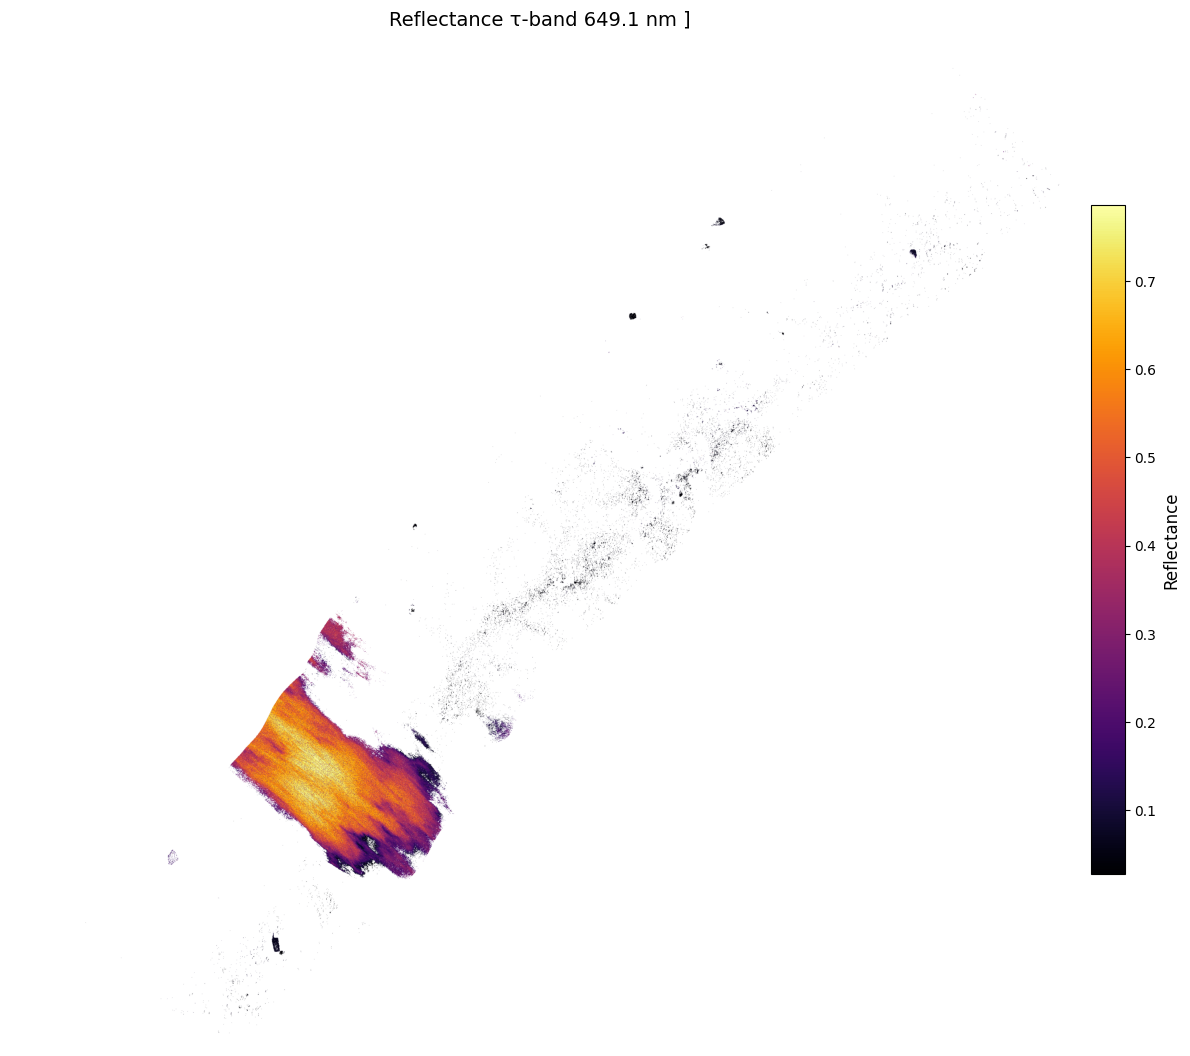

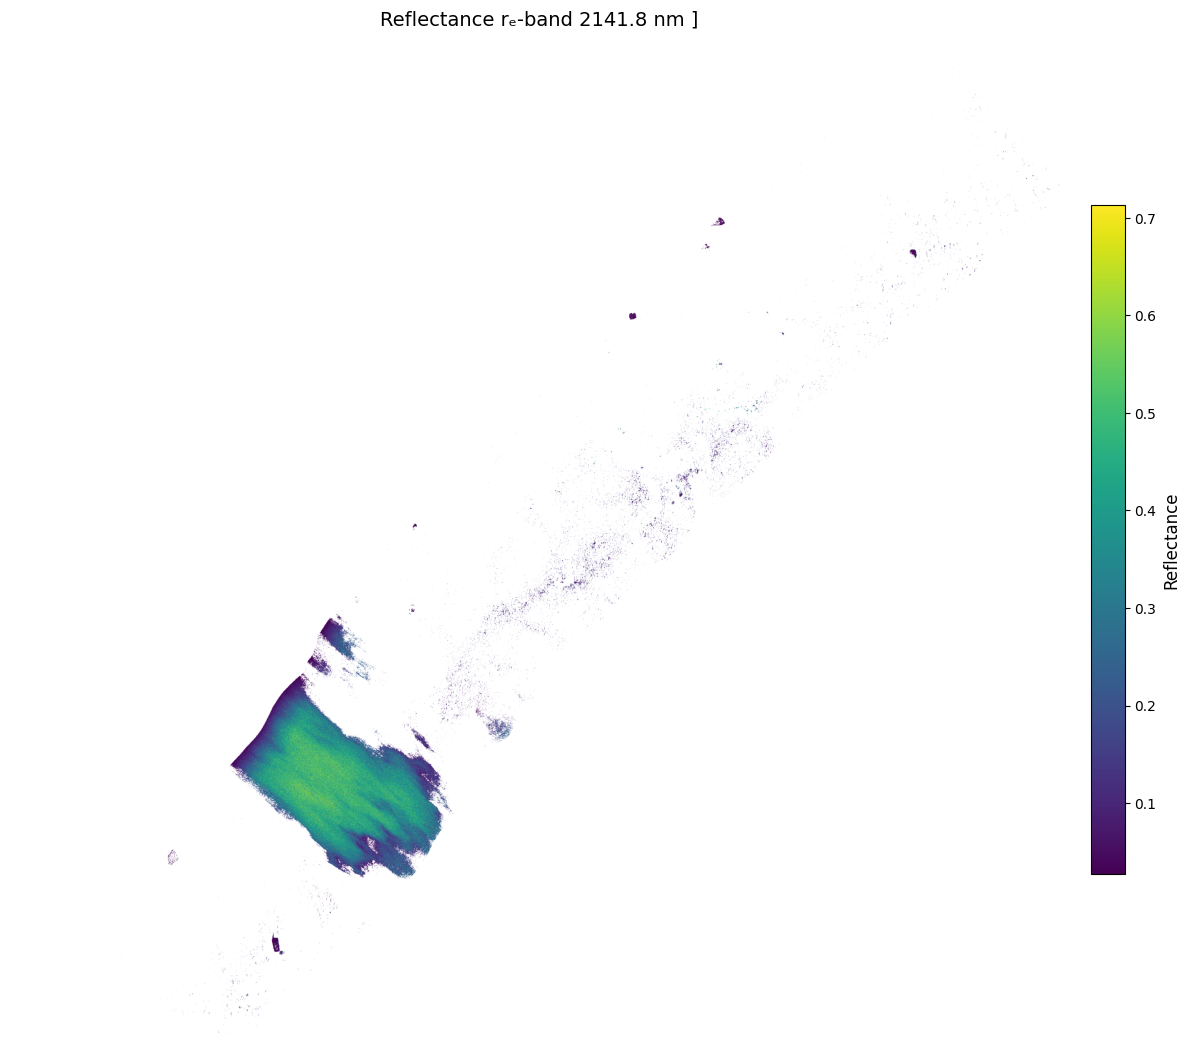

τ reflectance image shape: (3767, 3938)
rₑ reflectance image shape: (3767, 3938)


In [235]:

## Read the bands and plot the reflectance values for the re/tau channels
# ENVI bands are 1-based, spectral python is 0-based
refl_tau = img_refl.read_band(band_tau)      # reflectance at 858 nm (ocean) or 649 nm (land)
refl_re  = img_refl.read_band(band_re)       # reflectance at 2137 nm
# Apply cloud mask (upper_cloud_mask from CTH)
refl_tau_masked = np.where(upper_cloud_mask, refl_tau, np.nan)
refl_re_masked = np.where(upper_cloud_mask, refl_re, np.nan)
# Mask invalid values
refl_tau_masked = np.ma.masked_invalid(refl_tau_masked)
refl_re_masked  = np.ma.masked_invalid(refl_re_masked)
# -----------------------------
# 4. Plot τ-band reflectance
# -----------------------------
plot_image(
    refl_tau_masked,
    base_name=f"Reflectance τ-band {wavelengths[band_tau]:.1f} nm",
    cbar_label="Reflectance",
    cmap="inferno",
    mask_threshold=0.0005,      # remove dark background/ocean
    percentile_stretch=(1, 99)
)

# -----------------------------
# 5. Plot rₑ-band reflectance
# -----------------------------
plot_image(
    refl_re_masked,
    base_name=f"Reflectance rₑ-band {wavelengths[band_re]:.1f} nm",
    cbar_label="Reflectance",
    cmap="viridis",
    mask_threshold=0.0005,
    percentile_stretch=(1, 99)
)

print("τ reflectance image shape:",  refl_tau.shape)
print("rₑ reflectance image shape:", refl_re.shape)


In [236]:

# ---------------------------------------------------------
# 1. Mask invalid pixels
# ---------------------------------------------------------
mask = (refl_tau <= 0.01) | (refl_re <= 0.01)

refl_a_masked = refl_tau_masked.astype(float).copy()
refl_b_masked = refl_re_masked.astype(float).copy()

refl_a_masked[mask] = np.nan
refl_b_masked[mask] = np.nan

# Flatten
a_flat = refl_a_masked.ravel()
b_flat = refl_b_masked.ravel()

valid = ~np.isnan(a_flat) & ~np.isnan(b_flat)

pix_xy_valid = np.vstack([a_flat[valid], b_flat[valid]]).T

# ---------------------------------------------------------
# 2. LUT reflectance space
# ---------------------------------------------------------
lut_xy = lut[[band_tau_col, band_re_col]].values
lut_tau = lut["tau"].values
lut_re  = lut["re"].values

# ---------------------------------------------------------
# 3. Build KD-tree
# ---------------------------------------------------------
tree = cKDTree(lut_xy)

# Nearest-neighbour lookup
dist, idx = tree.query(pix_xy_valid)

tau_valid = lut_tau[idx]
re_valid  = lut_re[idx]

# ---------------------------------------------------------
# 4. Put results back into image shape
# ---------------------------------------------------------
tau_img = np.full_like(refl_a_masked, np.nan, dtype=float)
re_img  = np.full_like(refl_a_masked, np.nan, dtype=float)

tau_img.ravel()[valid] = tau_valid
re_img.ravel()[valid]  = re_valid


/home/danlab/.virtualenvs/python_LRT/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


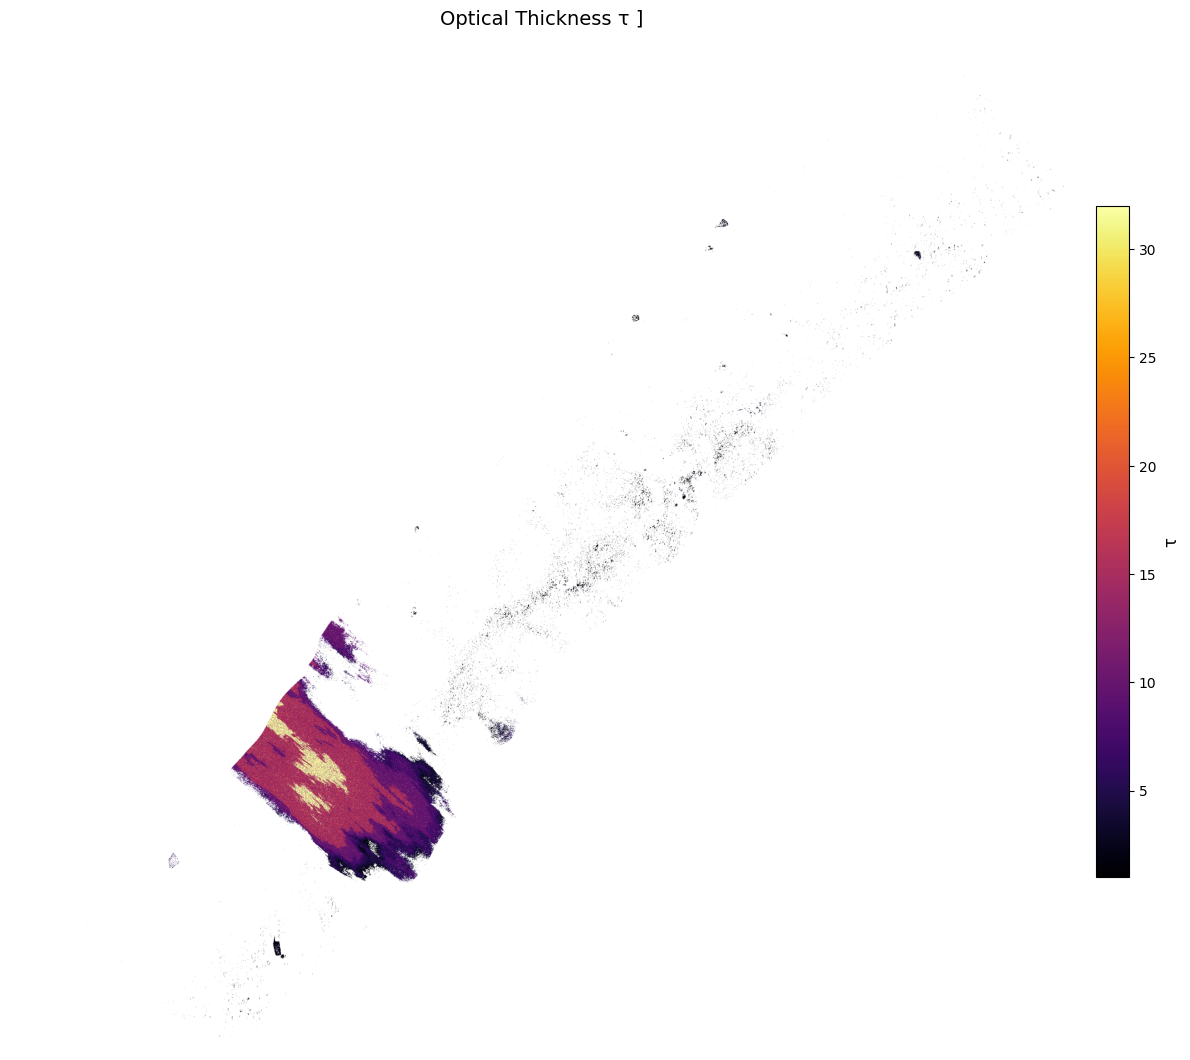

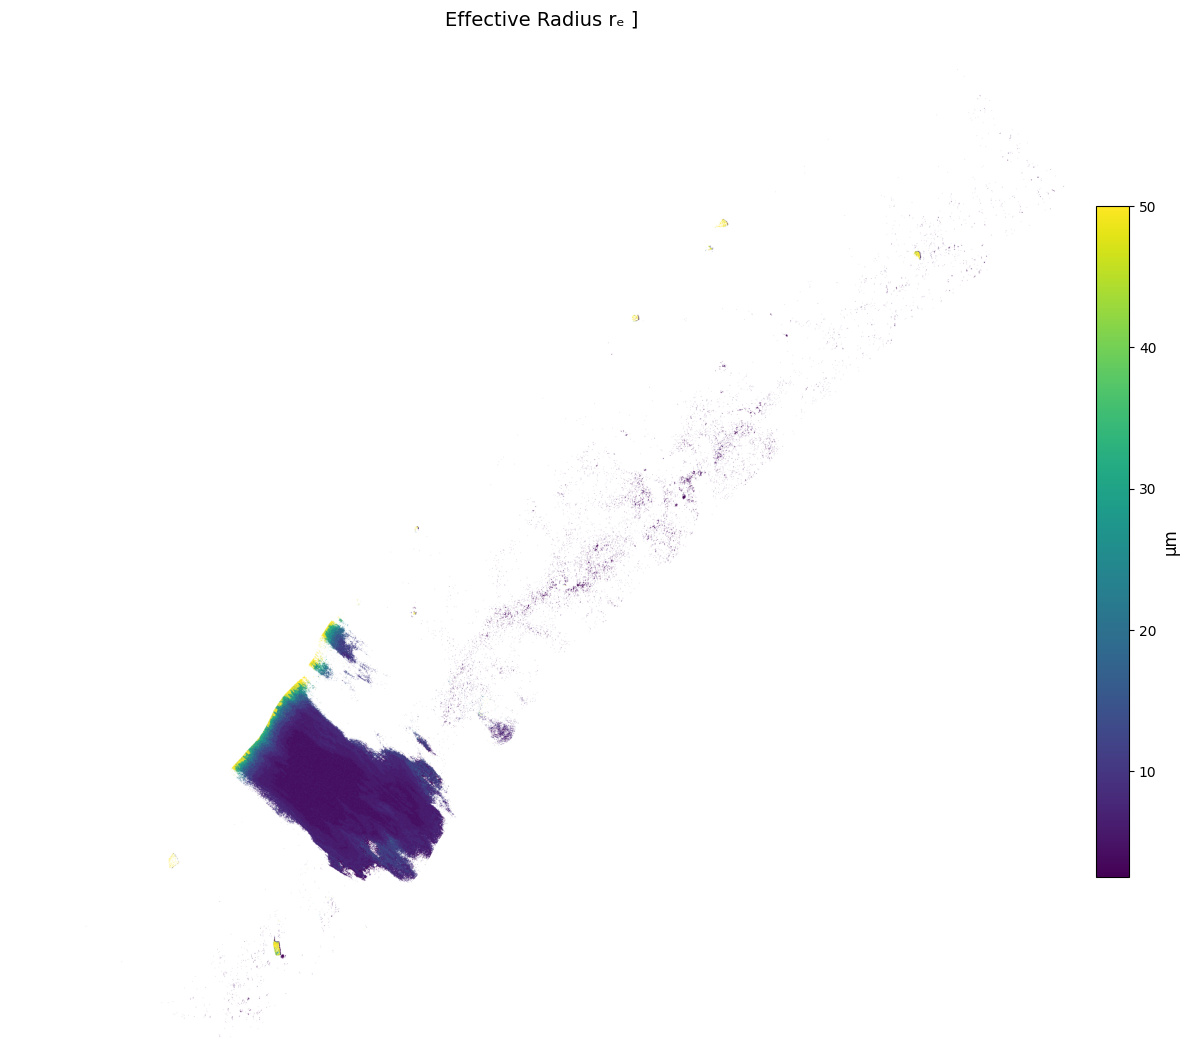

In [237]:
# These appear blocky because it gets the nearest neighbour of the LUT, is is the physically most realistic way
# There are some ways to interpolate but because the LUT is square it is not clear what the best way to do it is. 
# Most probably the best way is to compute the LUT at smaller intervals, once it is clear what type of values we expect. 

plot_image(tau_img, base_name="Optical Thickness τ",
           cbar_label="τ", cmap="inferno",
           mask_threshold=0.006, percentile_stretch=(2, 98))

plot_image(re_img, base_name="Effective Radius rₑ",
           cbar_label="µm", cmap="viridis",
           mask_threshold=0.006, percentile_stretch=(0, 98))

In [210]:
print(target_image_id)

20241208_8_01


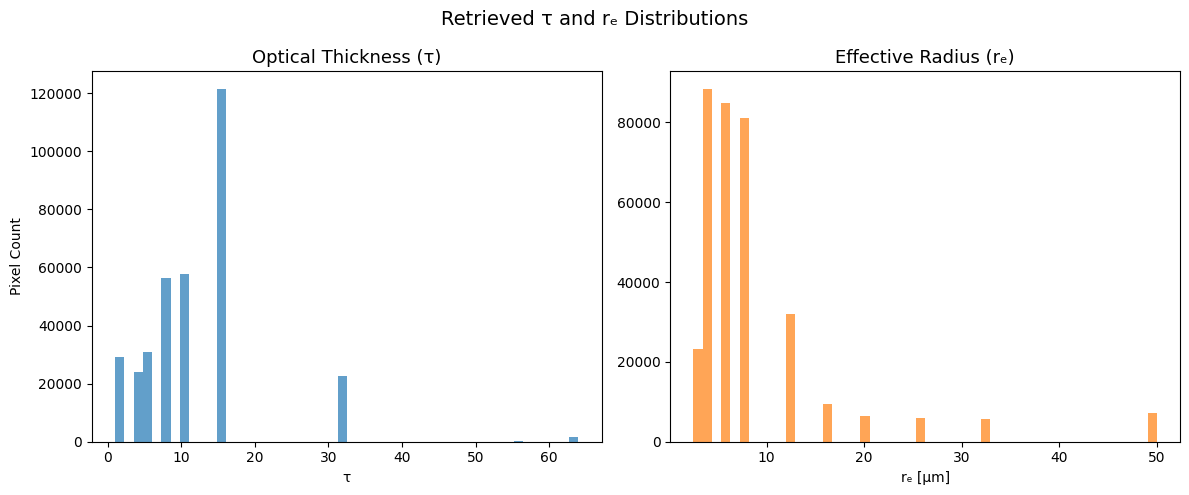

In [222]:
# ===============================================================
# τ and rₑ diagnostics
# ===============================================================
# Mask invalid values
tau_masked = np.ma.masked_invalid(tau_img)
re_masked  = np.ma.masked_invalid(re_img)

# --- Histogram diagnostics ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# τ histogram
axes[0].hist(tau_masked.compressed(), bins=50, color='tab:blue', alpha=0.7)
axes[0].set_title("Optical Thickness (τ)", fontsize=13)
axes[0].set_xlabel("τ")
axes[0].set_ylabel("Pixel Count")

# rₑ histogram
axes[1].hist(re_masked.compressed(), bins=50, color='tab:orange', alpha=0.7)
axes[1].set_title("Effective Radius (rₑ)", fontsize=13)
axes[1].set_xlabel("rₑ [µm]")

plt.suptitle("Retrieved τ and rₑ Distributions", fontsize=14)
plt.tight_layout()
plt.show()


In [241]:
list(lut)

['re',
 'tau',
 'solz',
 'cth_km',
 'cloud_temp',
 'refl_band082',
 'refl_band416',
 'index']

In [244]:
# LUT reflectance space
lut_xy = lut[["refl_band082", "refl_band416"]].values

lut_tau = lut["tau"].values
lut_re  = lut["re"].values
tau_flat = tau_img.ravel()
re_flat  = re_img.ravel()

valid = np.isfinite(tau_flat) & np.isfinite(re_flat)

pix_tr_valid = np.vstack([tau_flat[valid], re_flat[valid]]).T

# ---------------------------------------------------------
# 2. Build KD-tree in (tau, re) space
# ---------------------------------------------------------
tree_tr = cKDTree(np.vstack([lut_tau, lut_re]).T)

dist_tr, idx_tr = tree_tr.query(pix_tr_valid)

# Modelled reflectance from LUT
refl_tau_model = np.full_like(tau_img, np.nan, dtype=float)
refl_re_model  = np.full_like(tau_img, np.nan, dtype=float)

refl_tau_model.ravel()[valid] = lut["refl_band082"].values[idx_tr]
refl_re_model.ravel()[valid]  = lut["refl_band416"].values[idx_tr]

resid_tau = refl_tau_masked.astype(float) - refl_tau_model
resid_re  = refl_re_masked.astype(float)  - refl_re_model

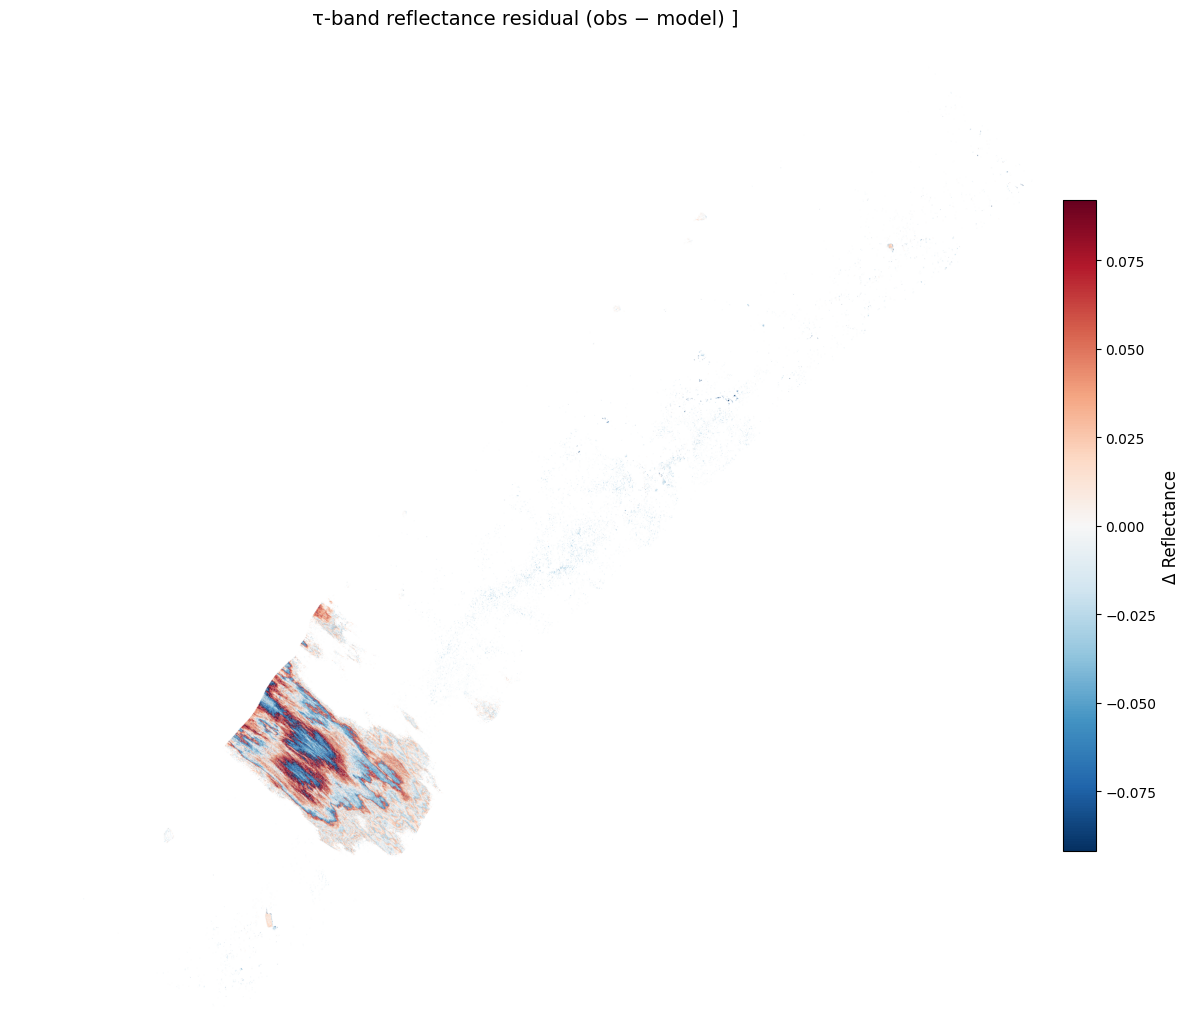

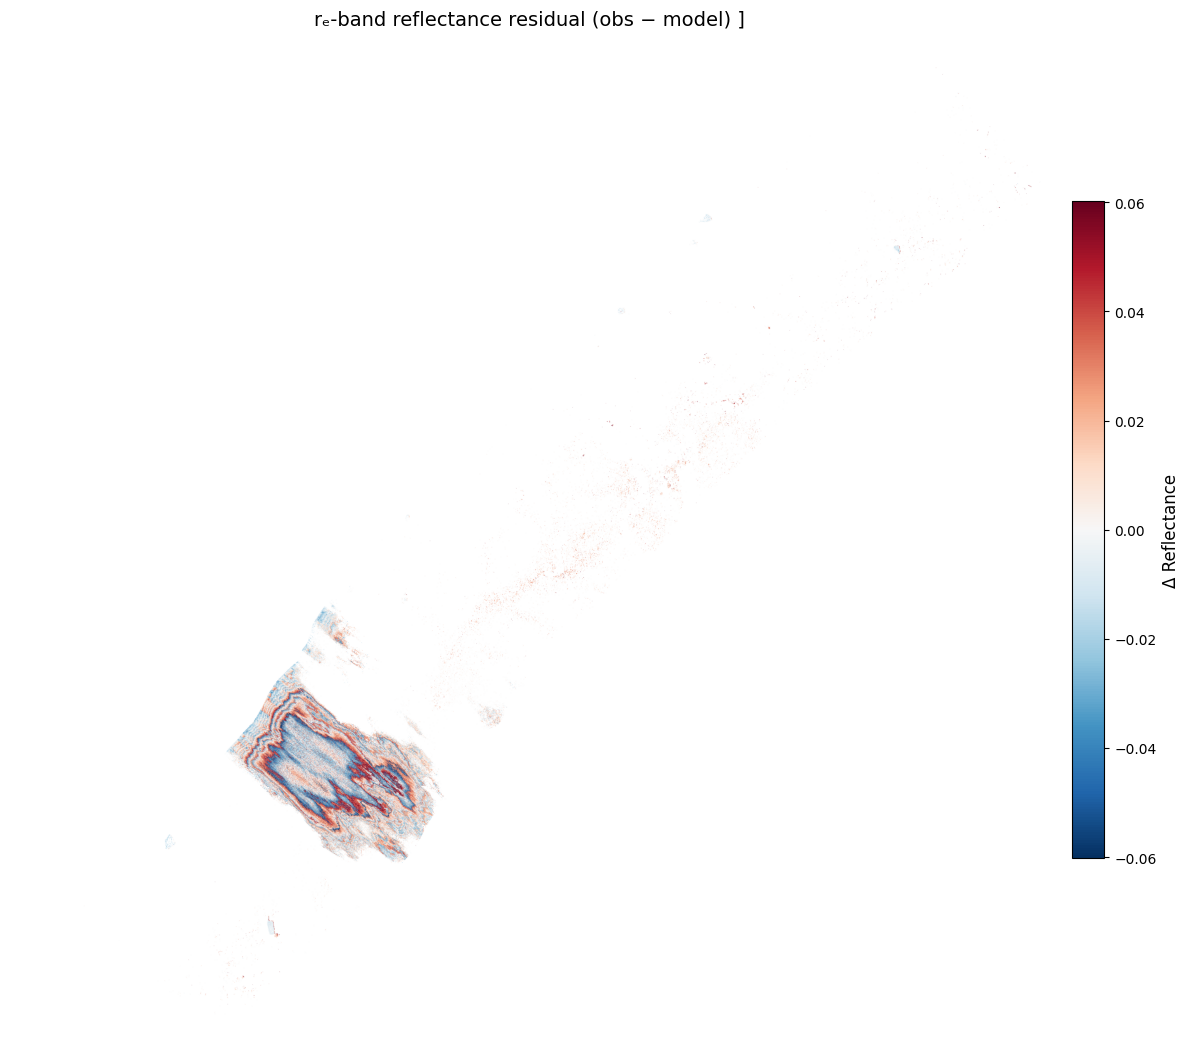

In [247]:
vals_tau = np.asarray(resid_tau[np.isfinite(resid_tau)], dtype=float)

if vals_tau.size == 0:
    lim_tau = 0.01   # safe fallback
else:
    lim_tau = np.percentile(np.abs(vals_tau), 98)

plot_image(
    resid_tau,
    base_name="τ-band reflectance residual (obs − model)",
    cbar_label="Δ Reflectance",
    cmap="RdBu_r",
    vmin=-lim_tau,
    vmax=lim_tau
)

vals_re = np.asarray(resid_re[np.isfinite(resid_re)], dtype=float)

if vals_re.size == 0:
    lim_re = 0.01
else:
    lim_re = np.percentile(np.abs(vals_re), 98)

plot_image(
    resid_re,
    base_name="rₑ-band reflectance residual (obs − model)",
    cbar_label="Δ Reflectance",
    cmap="RdBu_r",
    vmin=-lim_re,
    vmax=lim_re
)


In [248]:
print(imageID)

20241208_8_01
